In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

In [2]:
img=image.load_img(r'C:\Users\Neha\OneDrive\Pictures\Saved Pictures\N.jpg')

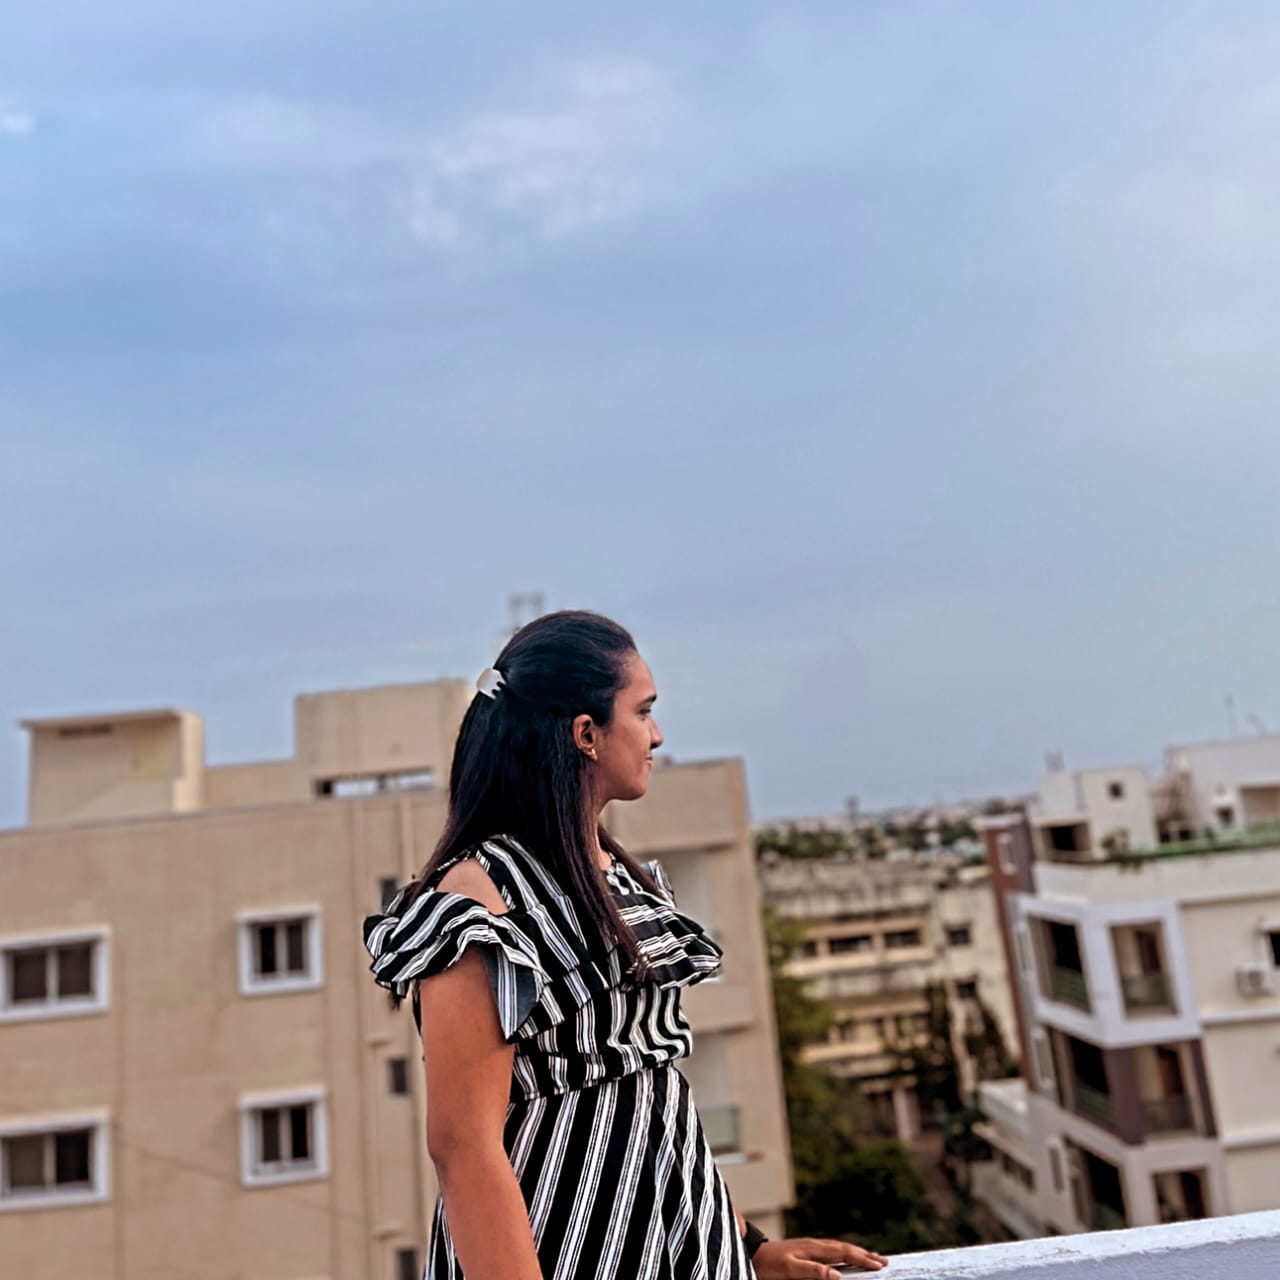

In [3]:
img

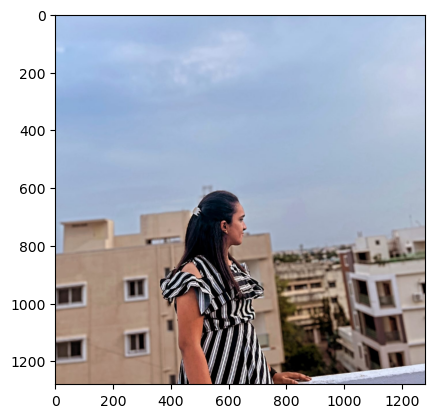

In [4]:
plt.imshow(img)

In [5]:
i=cv2.imread(r'C:\Users\Neha\OneDrive\Pictures\Saved Pictures\N.jpg')
i

array([[[240, 201, 173],
        [240, 201, 173],
        [240, 201, 173],
        ...,
        [234, 207, 186],
        [234, 207, 186],
        [234, 207, 186]],

       [[240, 201, 173],
        [240, 201, 173],
        [240, 201, 173],
        ...,
        [234, 207, 186],
        [234, 207, 186],
        [234, 207, 186]],

       [[240, 201, 173],
        [240, 201, 173],
        [240, 201, 173],
        ...,
        [234, 207, 186],
        [234, 207, 186],
        [234, 207, 186]],

       ...,

       [[120, 141, 173],
        [120, 141, 173],
        [120, 141, 173],
        ...,
        [192, 163, 159],
        [193, 164, 160],
        [192, 163, 159]],

       [[120, 141, 173],
        [120, 141, 173],
        [120, 141, 173],
        ...,
        [189, 160, 156],
        [190, 161, 157],
        [190, 161, 157]],

       [[120, 141, 173],
        [120, 141, 173],
        [120, 141, 173],
        ...,
        [187, 158, 154],
        [188, 159, 155],
        [188, 159, 155]]

In [6]:
i.shape

(1280, 1280, 3)

In [7]:
train=ImageDataGenerator(rescale=1/255)
validation=ImageDataGenerator(rescale=1/255)

In [8]:
train_dataset=train.flow_from_directory(r'D:\CNN (Happy NotHappy)\training',
                                        target_size=(200,200),
                                        batch_size=3,
                                        class_mode='binary')
validation_dataset=validation.flow_from_directory(r'D:\CNN (Happy NotHappy)\validation',
                                                  target_size=(200,200),
                                                  batch_size=3,
                                                  class_mode='binary')

Found 50 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [9]:
train_dataset.class_indices

{'Happy': 0, 'NotHappy': 1}

In [10]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1], dtype=int32)

In [11]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

C:\Users\Neha\Documents\it\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 198, 198, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 99, 99, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 97, 97, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 46, 46, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 33856)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      17,334,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['acc'])

In [14]:
model_fit=model.fit(train_dataset,
                   epochs=10) 

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - acc: 0.5400 - loss: 0.7692
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - acc: 0.5600 - loss: 0.6858
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step - acc: 0.7200 - loss: 0.5484
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - acc: 0.7400 - loss: 0.6537
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - acc: 0.9400 - loss: 0.2754
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - acc: 0.9200 - loss: 0.2169
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step - acc: 1.0000 - loss: 0.0473
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step - acc: 1.0000 - loss: 0.0199
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - acc: 1.0000 - loss: 0.0103
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - acc: 1.0000 - loss: 3.6666e-04
